# 🏥 TriageAI — SFT + RL Training
**Model:** Qwen2.5-3B-Instruct | **Method:** Expert SFT → GRPO RL | **Team:** Block Dragon

In [13]:
!pip install -q unsloth trl requests matplotlib datasets

In [14]:
import os, json, random, time, requests, torch
import matplotlib.pyplot as plt
from datasets import Dataset

ENV_URL = "https://hinex-07-triage-ai-env.hf.space"
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct"
OUTPUT_DIR = "./triage_ai_trained"
os.makedirs(OUTPUT_DIR, exist_ok=True)

r = requests.get(f"{ENV_URL}/health", timeout=30)
print(f"Environment: {r.json()}")

Environment: {'status': 'healthy', 'environment': 'TriageAI'}


In [15]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME, max_seq_length=4096, dtype=None, load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model, r=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=16, lora_dropout=0, bias="none", use_gradient_checkpointing="unsloth",
)
print(f"Loaded {MODEL_NAME}, trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded unsloth/Qwen2.5-3B-Instruct, trainable: 29,933,568


In [16]:
SYSTEM_PROMPT = """You are an expert Emergency Room triage physician AI. You manage a busy ER with limited beds, doctors, and one operating room.

GOAL: Save as many patients as possible by triaging, assigning resources, and treating efficiently.

ACTIONS (respond with EXACTLY one JSON object, nothing else):
1. {"action_type": "triage", "patient_id": "P001"}
2. {"action_type": "assign_bed", "patient_id": "P001"}
3. {"action_type": "assign_doctor", "patient_id": "P001", "params": {"doctor_id": 0}}
4. {"action_type": "order_treatment", "patient_id": "P001", "params": {"treatment": "medication"}}
5. {"action_type": "send_to_or", "patient_id": "P001"}
6. {"action_type": "discharge", "patient_id": "P001"}
7. {"action_type": "reassess", "patient_id": "P001"}
8. {"action_type": "submit"}

RULES:
- Triage critical patients FIRST (low SpO2, high HR, altered consciousness)
- Assign beds to urgent patients before stable ones
- Discharge non-urgent patients to free beds for critical ones
- Use OR for surgical emergencies only
- Respond with ONLY the JSON action object"""

def env_reset(task_id="task_easy", seed=None):
    seed = seed or random.randint(0,100000)
    return requests.post(f"{ENV_URL}/reset", json={"task_id":task_id,"seed":seed}, timeout=30).json()

def env_step(action):
    return requests.post(f"{ENV_URL}/step", json=action, timeout=30).json()

def format_obs(obs_data):
    obs = obs_data.get("observation", obs_data)
    lines = [f"=== ER (Step {obs.get('current_step',0)}/{obs.get('max_steps',0)}) ==="]
    lines.append(f"Action result: {obs.get('last_action_message','')}")
    s = obs.get("summary",{})
    lines.append(f"Patients: {s.get('total_patients',0)} total | {s.get('alive',0)} alive | {s.get('dead',0)} dead | {s.get('treated',0)} treated")
    h = obs.get("hospital",{})
    beds = h.get("beds",[])
    lines.append(f"Beds: {sum(1 for b in beds if not b.get('occupied'))}/{len(beds)} free")
    docs = h.get("doctors",[])
    lines.append(f"Doctors: {sum(1 for d in docs if not d.get('busy'))}/{len(docs)} available")
    or_i = h.get("or",{})
    or_status = "Available" if or_i.get('available') else "In use (cooldown " + str(or_i.get('cooldown_steps',0)) + ")"
    lines.append(f"OR: {or_status}")
    for p in obs.get("waiting_patients",[]):
        v = p.get("vitals",{})
        tl = f" [Triage: {p['triage_level']}]" if p.get("triage_level") else ""
        lines.append(f"[WAIT] {p['id']} {p.get('name','')}: {p.get('chief_complaint','')} | HR={v.get('hr')} SpO2={v.get('spo2')}%{tl}")
        lines.append(f"  Symptoms: {p.get('symptoms','')}")
    for p in obs.get("admitted_patients",[]):
        v = p.get("vitals",{})
        tl = f" [Triage: {p.get('triage_level','')}]" if p.get("triage_level") else ""
        notes = " | Notes: " + p['clinical_notes'] if p.get("clinical_notes") else ""
        lines.append(f"[BED] {p['id']} {p.get('name','')}: {p.get('chief_complaint','')} | HR={v.get('hr')} SpO2={v.get('spo2')}%{tl}{notes}")
    return "\n".join(lines)

def parse_action(text):
    text = text.strip()
    if '```' in text:
        text = text.split('```')[1] if len(text.split('```')) > 1 else text
    try:
        return json.loads(text[text.index('{'):text.rindex('}')+1])
    except:
        return {"action_type":"submit"}

print("Helpers loaded!")


Helpers loaded!


## Step 1: Generate Expert Training Data

In [17]:
def get_sev(p):
    v = p.get('vitals',{})
    hr,spo2,con = v.get('hr',80),v.get('spo2',98),v.get('consciousness','alert')
    if con=='unresponsive': return 1
    if con=='confused': return 2
    if spo2<85: return 1
    if spo2<92: return 2
    if hr>130: return 1
    if hr>110: return 2
    return 5

def needs_surg(p):
    t = f"{p.get('clinical_notes','')} {p.get('chief_complaint','')} {p.get('symptoms','')}".lower()
    return any(k in t for k in ['laceration','fracture','hemorrhage','hematoma','dissection','torsion','obstruction','appendicitis','surgery','surgical','bleeding','arterial','immediate intervention','visible muscle'])

def expert_action(obs_data):
    obs = obs_data.get('observation',obs_data)
    w,a = obs.get('waiting_patients',[]),obs.get('admitted_patients',[])
    h = obs.get('hospital',{})
    fb = sum(1 for b in h.get('beds',[]) if not b.get('occupied'))
    fd = sum(1 for d in h.get('doctors',[]) if not d.get('busy'))
    or_ok = h.get('or',{}).get('available',False)
    # 1. Triage untriaged
    ut = [p for p in w if not p.get('triage_level')]
    if ut:
        ut.sort(key=get_sev)
        return {'action_type':'triage','patient_id':ut[0]['id']}
    # 2. Discharge stable admitted to free beds
    if fb == 0 and w:
        for p in sorted(a, key=lambda x: -(x.get('triage_level',5) or 5)):
            if (p.get('triage_level') or 5) >= 4:
                return {'action_type':'discharge','patient_id':p['id']}
    # 3. Assign beds to critical waiting
    if fb > 0 and w:
        sw = sorted(w, key=lambda p: p.get('triage_level',5))
        return {'action_type':'assign_bed','patient_id':sw[0]['id']}
    # 4. Assign doctors
    if fd > 0:
        for p in sorted(a, key=lambda x: x.get('triage_level',5) or 5):
            if not p.get('examined') and not p.get('clinical_notes'):
                return {'action_type':'assign_doctor','patient_id':p['id'],'params':{}}
    # 5. Treat examined
    for p in a:
        if p.get('clinical_notes') or p.get('examined'):
            if needs_surg(p) and or_ok:
                return {'action_type':'send_to_or','patient_id':p['id']}
            return {'action_type':'order_treatment','patient_id':p['id'],'params':{'treatment':'medication'}}
    # 6. Discharge remaining stable
    for p in a:
        if (p.get('triage_level') or 5) >= 4:
            return {'action_type':'discharge','patient_id':p['id']}
    for p in w:
        if (p.get('triage_level') or 5) >= 4:
            return {'action_type':'discharge','patient_id':p['id']}
    return {'action_type':'submit'}

print('Expert agent ready!')

Expert agent ready!


In [18]:
# Generate expert demonstrations
sft_data = []
expert_scores, expert_survivals = [], []

# DRY RUN: use 5/5/3. FULL RUN: use 40/40/20
tasks = [('task_easy',40),('task_medium',40),('task_hard',20)]

for task_id, n_eps in tasks:
    print(f'\n--- {task_id} ({n_eps} episodes) ---')
    for ep in range(n_eps):
        try:
            obs = env_reset(task_id, random.randint(0,100000))
            done, step = False, 0

            while not done and step < 40:
                obs_text = format_obs(obs)
                action = expert_action(obs)

                sft_data.append({
                    'messages':[
                        {'role':'system','content':SYSTEM_PROMPT},
                        {'role':'user','content':obs_text},
                        {'role':'assistant','content':json.dumps(action)}
                    ]
                })

                obs = env_step(action)
                done = obs.get('done', False)
                step += 1

            # --- Extract episode stats ---
            meta = obs.get('observation', {}).get('metadata', {})
            score = meta.get('composite_score', 0)
            survival = meta.get('survival_rate', 0)

            expert_scores.append(score)
            expert_survivals.append(survival)

            # --- Logging ---
            recent_scores = expert_scores[-min(10, len(expert_scores)):]
            recent_surv = expert_survivals[-min(10, len(expert_survivals)):]

            print(
                f'  Ep {ep+1}: '
                f'examples={len(sft_data)} '
                f'avg_score={sum(recent_scores)/len(recent_scores):.3f} '
                f'avg_surv={sum(recent_surv)/len(recent_surv):.3f}'
            )

        except Exception as e:
            print(f'  Error: {e}')
            time.sleep(1)

# --- Summary ---
print(f'\nTotal SFT examples: {len(sft_data)}')

if len(expert_scores) > 0:
    print(f'Expert avg score: {sum(expert_scores)/len(expert_scores):.3f}')
    print(f'Expert avg survival: {sum(expert_survivals)/len(expert_survivals):.3f}')
else:
    print("⚠️ No successful episodes recorded")


--- task_easy (40 episodes) ---
  Ep 1: examples=12 avg_score=0.618 avg_surv=0.500
  Ep 2: examples=27 avg_score=0.610 avg_surv=0.500
  Ep 3: examples=40 avg_score=0.637 avg_surv=0.500
  Ep 4: examples=53 avg_score=0.650 avg_surv=0.500
  Ep 5: examples=67 avg_score=0.643 avg_surv=0.500
  Ep 6: examples=80 avg_score=0.651 avg_surv=0.500
  Ep 7: examples=93 avg_score=0.645 avg_surv=0.500
  Ep 8: examples=110 avg_score=0.651 avg_surv=0.531
  Ep 9: examples=127 avg_score=0.656 avg_surv=0.556
  Ep 10: examples=140 avg_score=0.659 avg_surv=0.550
  Ep 11: examples=157 avg_score=0.672 avg_surv=0.575
  Ep 12: examples=170 avg_score=0.674 avg_surv=0.575
  Ep 13: examples=183 avg_score=0.666 avg_surv=0.575
  Ep 14: examples=196 avg_score=0.658 avg_surv=0.575
  Ep 15: examples=210 avg_score=0.657 avg_surv=0.575
  Ep 16: examples=223 avg_score=0.658 avg_surv=0.575
  Ep 17: examples=236 avg_score=0.658 avg_surv=0.575
  Ep 18: examples=255 avg_score=0.657 avg_surv=0.575
  Ep 19: examples=269 avg_sco

## Step 2: Baseline Evaluation (Before Training)

In [19]:
def run_eval(model, tokenizer, task_id='task_easy', n=3):
    scores, survs = [], []
    FastLanguageModel.for_inference(model)
    for ep in range(n):
        obs = env_reset(task_id, seed=ep*100)
        done, steps = False, 0
        while not done and steps < 20:
            obs_text = format_obs(obs)
            msgs = [{'role':'system','content':SYSTEM_PROMPT},{'role':'user','content':obs_text}]
            inp = tokenizer(tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True), return_tensors='pt').to(model.device)
            with torch.no_grad():
                out = model.generate(**inp, max_new_tokens=200, temperature=0.1, do_sample=True)
            resp = tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
            obs = env_step(parse_action(resp))
            done = obs.get('done',False)
            steps += 1
        m = obs.get('observation',{}).get('metadata',{})
        scores.append(m.get('composite_score',0))
        survs.append(m.get('survival_rate',0))
    return sum(scores)/len(scores), sum(survs)/len(survs)

print('=== BASELINE (Before Training) ===')
baseline = {}
for t in ['task_easy','task_medium','task_hard']:
    s,v = run_eval(model, tokenizer, t, 3)
    baseline[t] = (s,v)
    print(f'  {t}: score={s:.3f} survival={v:.3f}')

=== BASELINE (Before Training) ===


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

  task_easy: score=0.448 survival=0.250


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  task_medium: score=0.518 survival=0.286


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  task_hard: score=0.535 survival=0.200


## Step 3: SFT Training on Expert Data

Map:   0%|          | 0/1792 [00:00<?, ? examples/s]

SFT dataset: 1792 examples


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1792 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Starting SFT training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,792 | Num Epochs = 5 | Total steps = 1,120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,1.919282
20,1.037633
30,0.439283
40,0.256310
50,0.182626
60,0.145559
70,0.125364
80,0.121283
90,0.119095
100,0.117090


Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-700/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/checkpoint-900/tokenizer_config.json.
Unsloth: Restored a

Training done! Loss: 0.1044


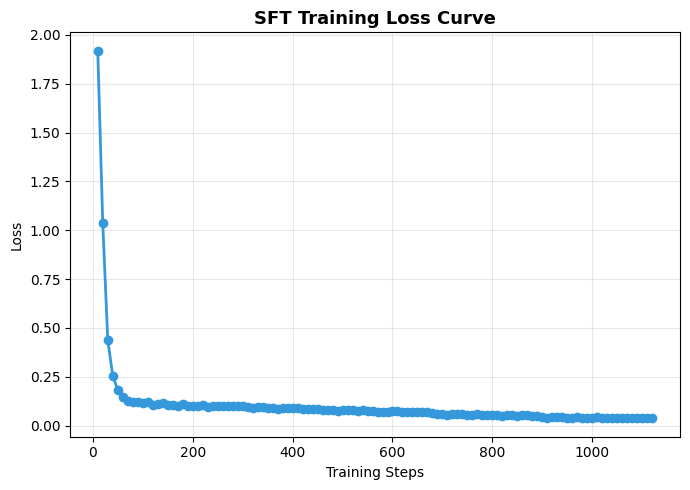

Saved loss_curve.png


In [20]:
from trl import SFTTrainer, SFTConfig

# Convert to HF Dataset
def format_for_sft(example):
    return {'text': tokenizer.apply_chat_template(example['messages'], tokenize=False, add_generation_prompt=False)}

ds = Dataset.from_list(sft_data)
ds = ds.map(format_for_sft)
print(f'SFT dataset: {len(ds)} examples')

FastLanguageModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=ds,
    args=SFTConfig(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=5,
        learning_rate=2e-4,
        warmup_steps=10,
        logging_steps=10,
        save_steps=100,
        max_seq_length=4096,
        dataset_text_field='text',
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
    ),
)

print('Starting SFT training...')
results = trainer.train()
print(f'Training done! Loss: {results.training_loss:.4f}')


# === Extract loss curve from trainer logs ===
loss_steps = []
loss_values = []

for log in trainer.state.log_history:
    if "loss" in log:
        loss_steps.append(log.get("step", len(loss_steps)))
        loss_values.append(log["loss"])

# === Plot loss curve ===
if len(loss_values) > 0:
    plt.figure(figsize=(7,5))

    plt.plot(loss_steps, loss_values, marker='o', linewidth=2, color='#3498db')

    plt.title("SFT Training Loss Curve", fontsize=13, fontweight='bold')
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig("loss_curve.png", dpi=150)  # save file
    plt.show()                              # 👈 display in Kaggle
    plt.close()

    print("Saved loss_curve.png")
else:
    print("⚠️ No loss logs found — check logging_steps or trainer config")

## Step 4: Post-Training Evaluation

=== AFTER SFT TRAINING ===


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2

  task_easy: score=0.656 survival=0.583


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  task_medium: score=0.638 survival=0.429


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  task_hard: score=0.608 survival=0.267


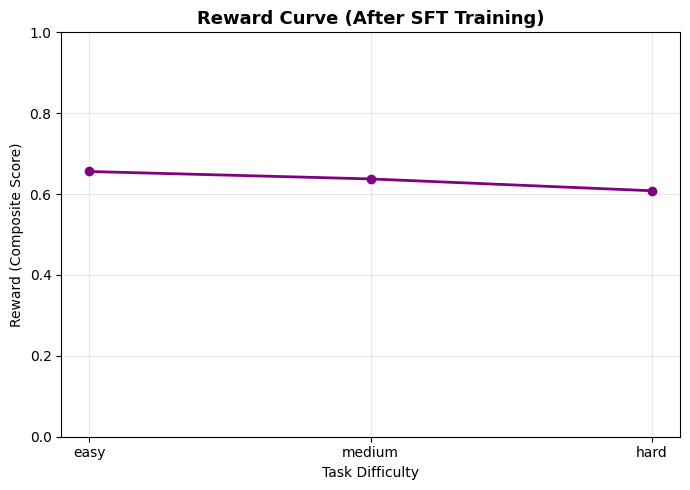

Saved reward_curve.png

=== IMPROVEMENT ===
  task_easy: score 0.448 -> 0.656 (+0.208) | survival 0.250 -> 0.583 (+0.333)
  task_medium: score 0.518 -> 0.638 (+0.120) | survival 0.286 -> 0.429 (+0.143)
  task_hard: score 0.535 -> 0.608 (+0.073) | survival 0.200 -> 0.267 (+0.067)


In [21]:
print('=== AFTER SFT TRAINING ===')

after = {}
reward_curve = []

# =========================================================
# 📊 POST-TRAINING EVALUATION
# =========================================================
for t in ['task_easy', 'task_medium', 'task_hard']:
    s, v = run_eval(model, tokenizer, t, 3)
    after[t] = (s, v)

    reward_curve.append(s)

    print(f'  {t}: score={s:.3f} survival={v:.3f}')

# =========================================================
# 📈 REWARD CURVE (AFTER TRAINING)
# =========================================================
plt.figure(figsize=(7,5))

plt.plot(['easy', 'medium', 'hard'],
         reward_curve,
         marker='o',
         linewidth=2,
         color='purple')

plt.title("Reward Curve (After SFT Training)", fontsize=13, fontweight='bold')
plt.xlabel("Task Difficulty")
plt.ylabel("Reward (Composite Score)")

plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("reward_curve.png", dpi=150)  # saved in /kaggle/working
plt.show()                                # display in notebook
plt.close()

print("Saved reward_curve.png")


# =========================================================
# 📊 IMPROVEMENT REPORT (UNCHANGED BUT CLEAN)
# =========================================================
print('\n=== IMPROVEMENT ===')

for t in ['task_easy', 'task_medium', 'task_hard']:
    bs, bv = baseline[t]
    a_s, av = after[t]

    print(
        f'  {t}: score {bs:.3f} -> {a_s:.3f} (+{a_s-bs:.3f}) | '
        f'survival {bv:.3f} -> {av:.3f} (+{av-bv:.3f})'
    )

## Step 5: Training Curves & Comparison

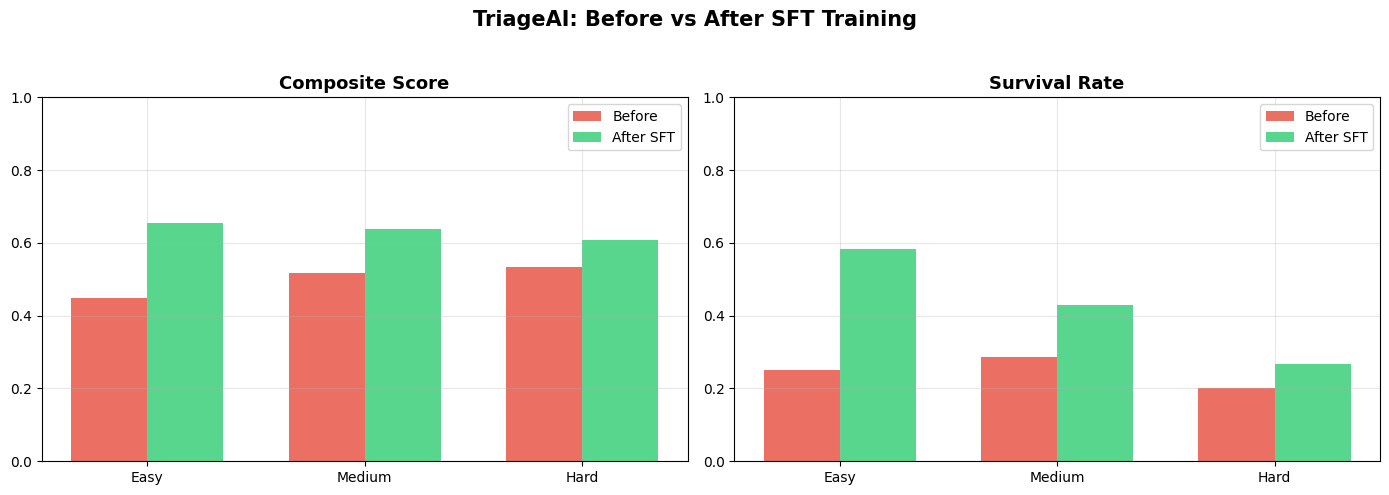

Saved training_curves.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before/After bar chart
tasks = ['task_easy','task_medium','task_hard']
x = range(len(tasks))
w = 0.35

before_scores = [baseline[t][0] for t in tasks]
after_scores = [after[t][0] for t in tasks]
before_surv = [baseline[t][1] for t in tasks]
after_surv = [after[t][1] for t in tasks]

# --- Composite Score ---
axes[0].bar([i-w/2 for i in x], before_scores, w, label='Before', color='#e74c3c', alpha=0.8)
axes[0].bar([i+w/2 for i in x], after_scores, w, label='After SFT', color='#2ecc71', alpha=0.8)
axes[0].set_title('Composite Score', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(['Easy','Medium','Hard'])
axes[0].set_ylim(0,1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Survival Rate ---
axes[1].bar([i-w/2 for i in x], before_surv, w, label='Before', color='#e74c3c', alpha=0.8)
axes[1].bar([i+w/2 for i in x], after_surv, w, label='After SFT', color='#2ecc71', alpha=0.8)
axes[1].set_title('Survival Rate', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(['Easy','Medium','Hard'])
axes[1].set_ylim(0,1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Title + Layout ---
plt.suptitle('TriageAI: Before vs After SFT Training', fontsize=15, fontweight='bold')

# Important: adjust BEFORE saving to avoid cut title
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save + Show
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')  # save file
plt.show()                                                        # display in Kaggle
plt.close()                                                       # free memory

print('Saved training_curves.png')

In [27]:
print('\n' + '='*90)
print(f"{'Task':<15} {'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10} {'% Improve':>12}")
print('='*90)

for t in ['task_easy','task_medium','task_hard']:
    bs, bv = baseline[t]
    a_s, av = after[t]
    
    score_change = a_s - bs
    surv_change = av - bv
    
    score_pct = (score_change / bs) * 100 if bs != 0 else 0
    surv_pct = (surv_change / bv) * 100 if bv != 0 else 0

    print(f"{t:<15} {'Score':<12} {bs:>10.3f} {a_s:>10.3f} {score_change:>+10.3f} {score_pct:>11.2f}%")
    print(f"{'':<15} {'Survival':<12} {bv:>10.3f} {av:>10.3f} {surv_change:>+10.3f} {surv_pct:>11.2f}%")
    print('-'*90)

print('='*90)


Task            Metric           Before      After     Change    % Improve
task_easy       Score             0.448      0.656     +0.208       46.38%
                Survival          0.250      0.583     +0.333      133.33%
------------------------------------------------------------------------------------------
task_medium     Score             0.518      0.638     +0.120       23.16%
                Survival          0.286      0.429     +0.143       50.02%
------------------------------------------------------------------------------------------
task_hard       Score             0.535      0.608     +0.073       13.72%
                Survival          0.200      0.267     +0.067       33.33%
------------------------------------------------------------------------------------------


In [24]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Model saved to {OUTPUT_DIR}')

Unsloth: Restored added_tokens_decoder metadata in ./triage_ai_trained/tokenizer_config.json.


Model saved to ./triage_ai_trained


In [25]:
import os
print(os.listdir("/kaggle/working"))

['unsloth_compiled_cache', 'huggingface_tokenizers_cache', 'loss_curve.png', 'reward_curve.png', 'training_curves.png', 'triage_ai_trained', '.virtual_documents']


(np.float64(-0.5), np.float64(2084.5), np.float64(740.5), np.float64(-0.5))

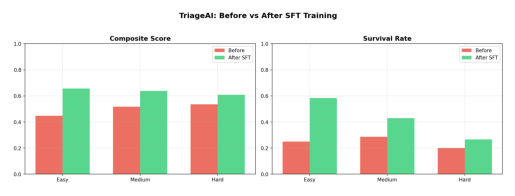

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/training_curves.png")
plt.imshow(img)
plt.axis('off')